# SBI with cosmoGRID l1-norms

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change "1" to the desired GPU index
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"  # Use 50% of GPU memory
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from jaxili.inference import NPE

# device = jax.devices("gpu")[0] 
print("Device used by jax:", jax.devices())

# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform" # Avoids preallocation of GPU memory

Device used by jax: [CudaDevice(id=0)]


In [154]:
params = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params_baryonified.npy', allow_pickle=True)

# **BIN 1**

In [155]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin1_baryonified.npy', allow_pickle=True)

In [156]:
params.shape, l1_full.shape

((16966, 6), (16966, 5, 40))

## Scale 1

In [157]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16966, 40)

In [158]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [159]:
dataset = (params, l1_scale1)

In [160]:
inference = NPE()

In [161]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [162]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin1_scale1"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -9.861/ Best val loss -9.890:  15%|█▌        | 153/1000 [00:52<04:50,  2.92it/s]

Neural network training stopped after 154 epochs.
Early stopping with best validation metric: -9.89016056060791
Best model saved at epoch 133
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -10.091259956359863
[!] Validation loss: -9.89016056060791
[!] Test loss: -9.908080101013184


In [163]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [164]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1.npy', allow_pickle=True)

In [165]:
np.array(fid_full).shape

(200, 5, 40)

In [166]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [167]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [168]:
import jax.random as random

master_key = random.PRNGKey(1)

In [169]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [170]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [171]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


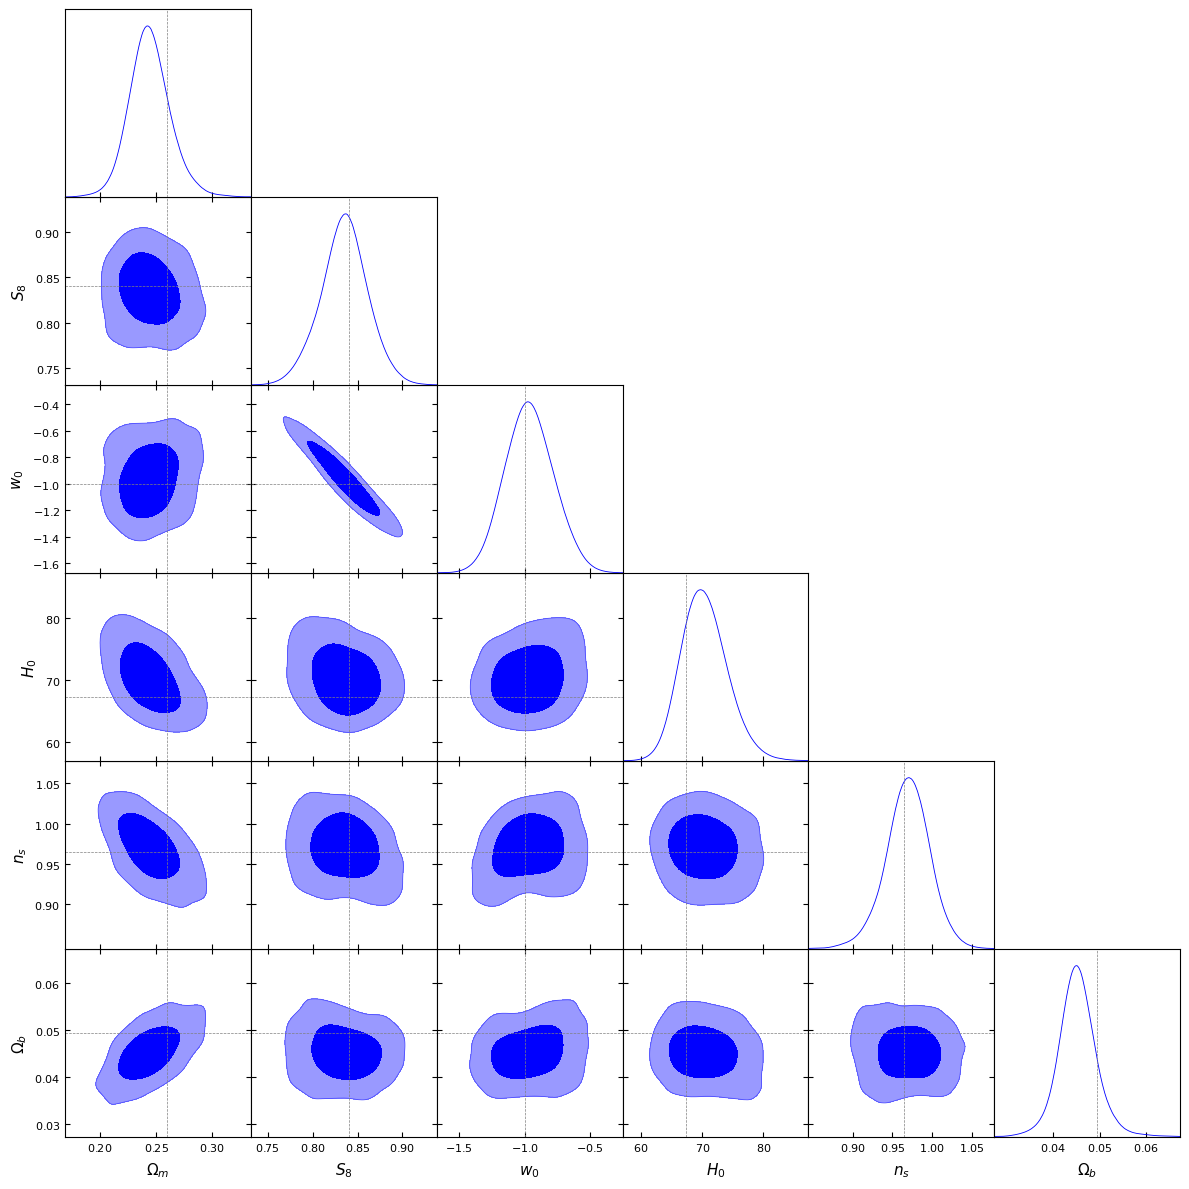

In [172]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_bar_bin1_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_bar_bin1_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [174]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_npe.npy", samples_bar_bin1_scale1.samples)

## Scale 2

In [87]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16966, 40)

In [88]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)
dataset = (params, l1_scale2)

In [89]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [90]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin1_scale2"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -8.629/ Best val loss -8.656:  16%|█▌        | 158/1000 [00:52<04:41,  3.00it/s]

Neural network training stopped after 159 epochs.
Early stopping with best validation metric: -8.655928611755371
Best model saved at epoch 138
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.767763137817383
[!] Validation loss: -8.655928611755371
[!] Test loss: -8.62487506866455


In [91]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [92]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [93]:
import jax.random as random

master_key = random.PRNGKey(1)

In [94]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [95]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [102]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


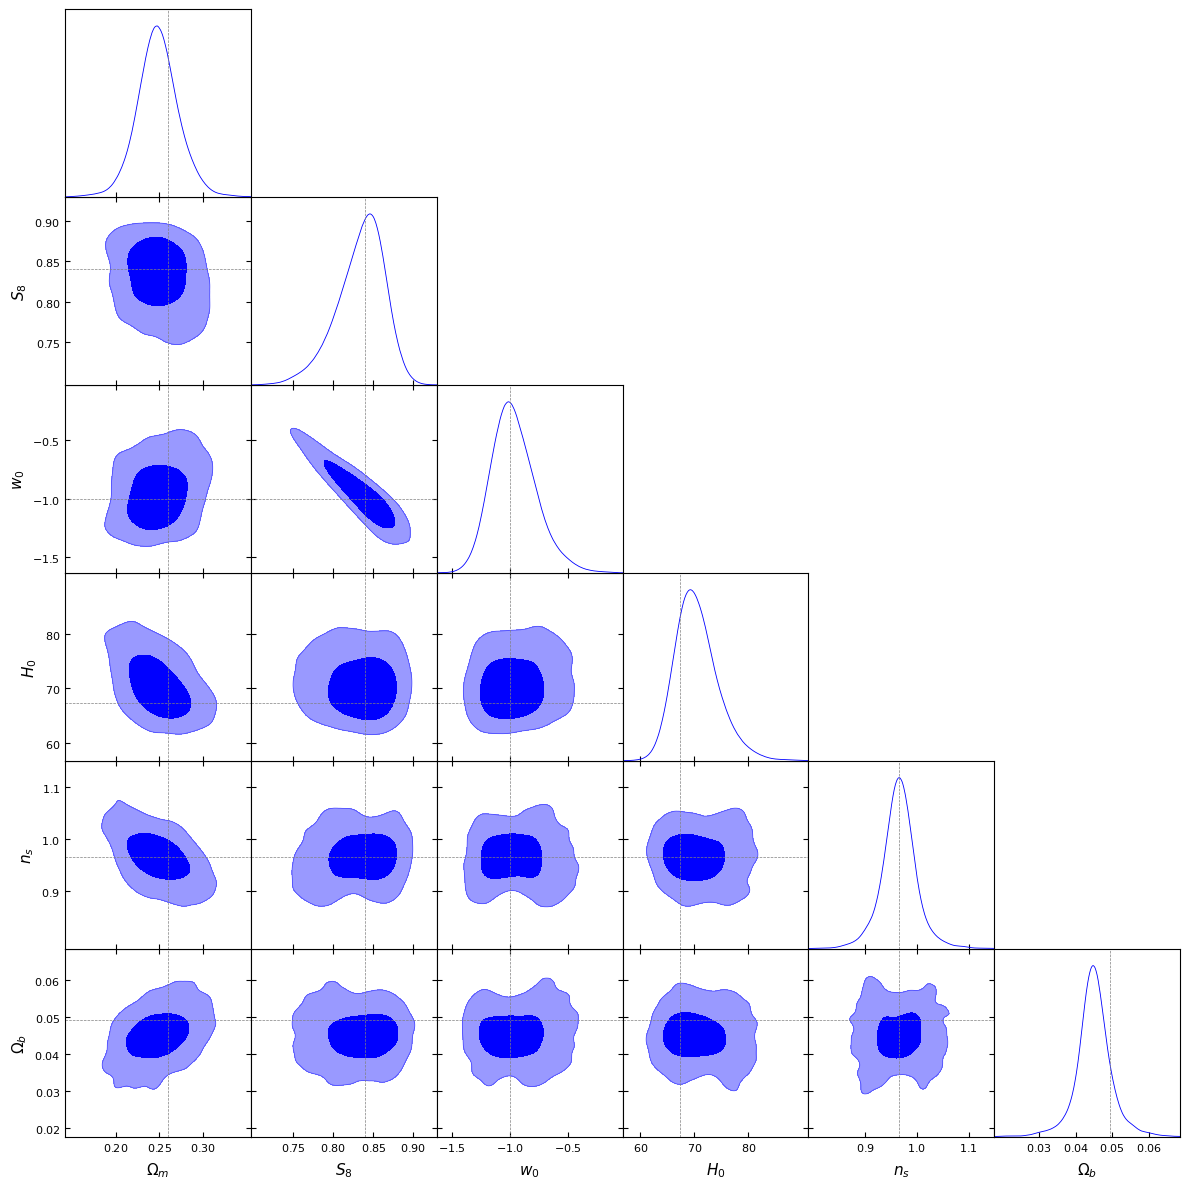

In [97]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_bar_bin1_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_bar_bin1_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [109]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin2_npe.npy", samples_bar_bin1_scale2)

# Compare Bar vs No Bar

## Scale 1

In [175]:
samples1_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_npe.npy", allow_pickle=True)
samples1_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin1_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [176]:
samples1_bar = MCSamples(
    samples=samples1_bar,
    names=labels,
    label="Bar, bin1, scale1",
)
samples1_nobar = MCSamples(
    samples=samples1_nobar,
    names=labels,
    label="NoBar, bin1, scale1",
)

Removed no burn in
Removed no burn in


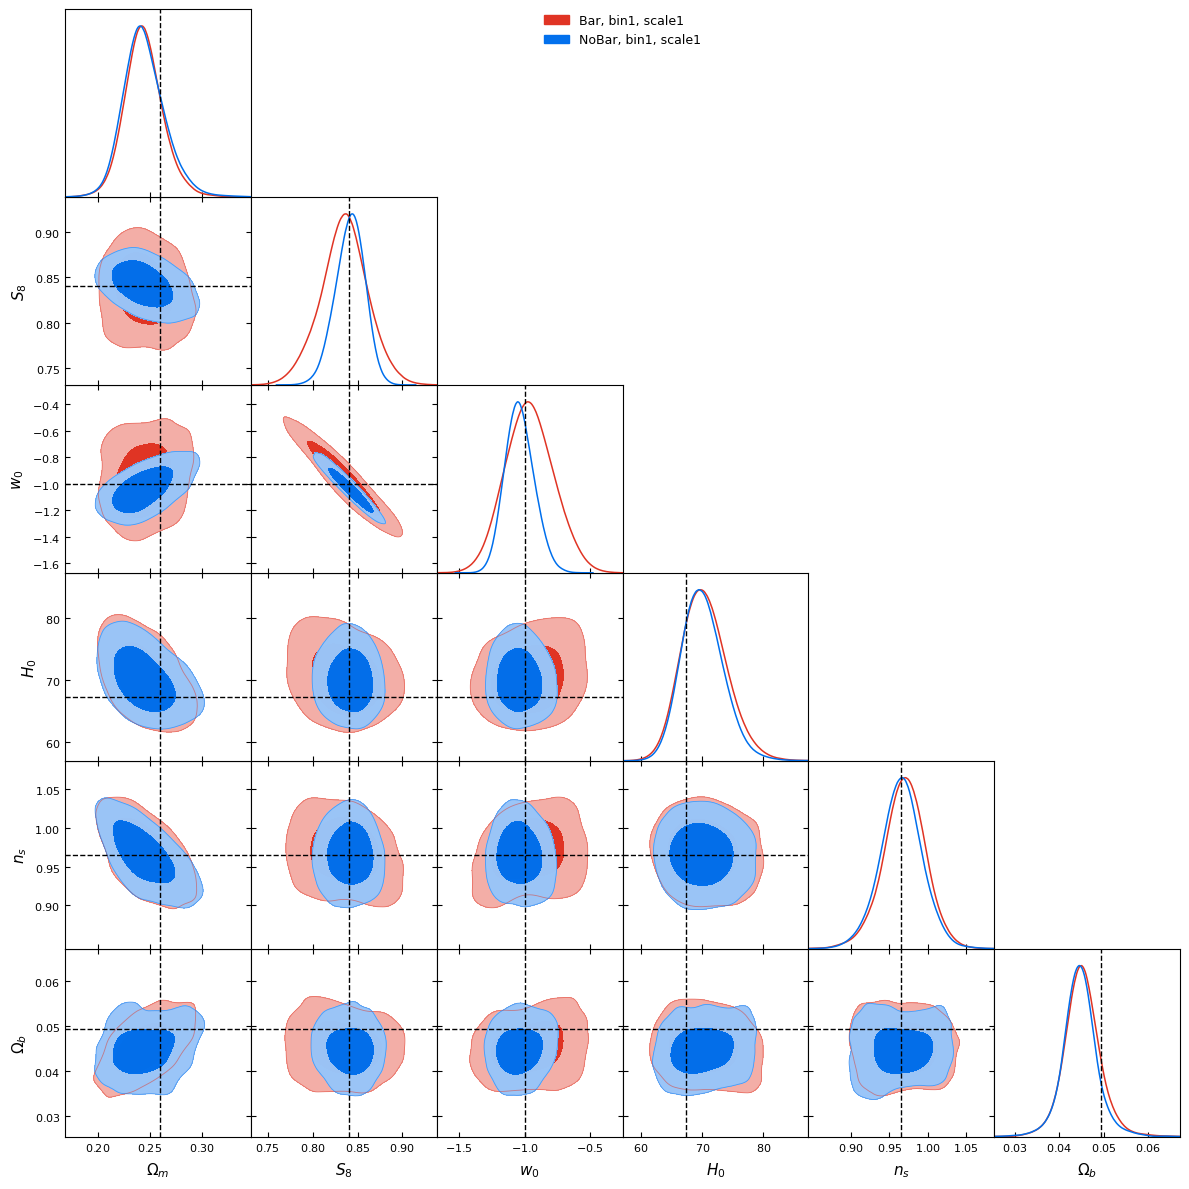

In [179]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples1_bar, samples1_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/NoBar_vs_bar_bin1_scale1_npe.pdf")
plt.show()

## Scale 2

In [13]:
samples2_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin2_npe.npy", allow_pickle=True)
samples2_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin1_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [14]:
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

samples2_bar = MCSamples(
    samples=samples2_bar,
    names=labels,
    label="Bar, bin1, scale2",
)
samples2_nobar = MCSamples(
    samples=samples2_nobar,
    names=labels,
    label="NoBar, bin1, scale2",
)

Removed no burn in
Removed no burn in


In [15]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

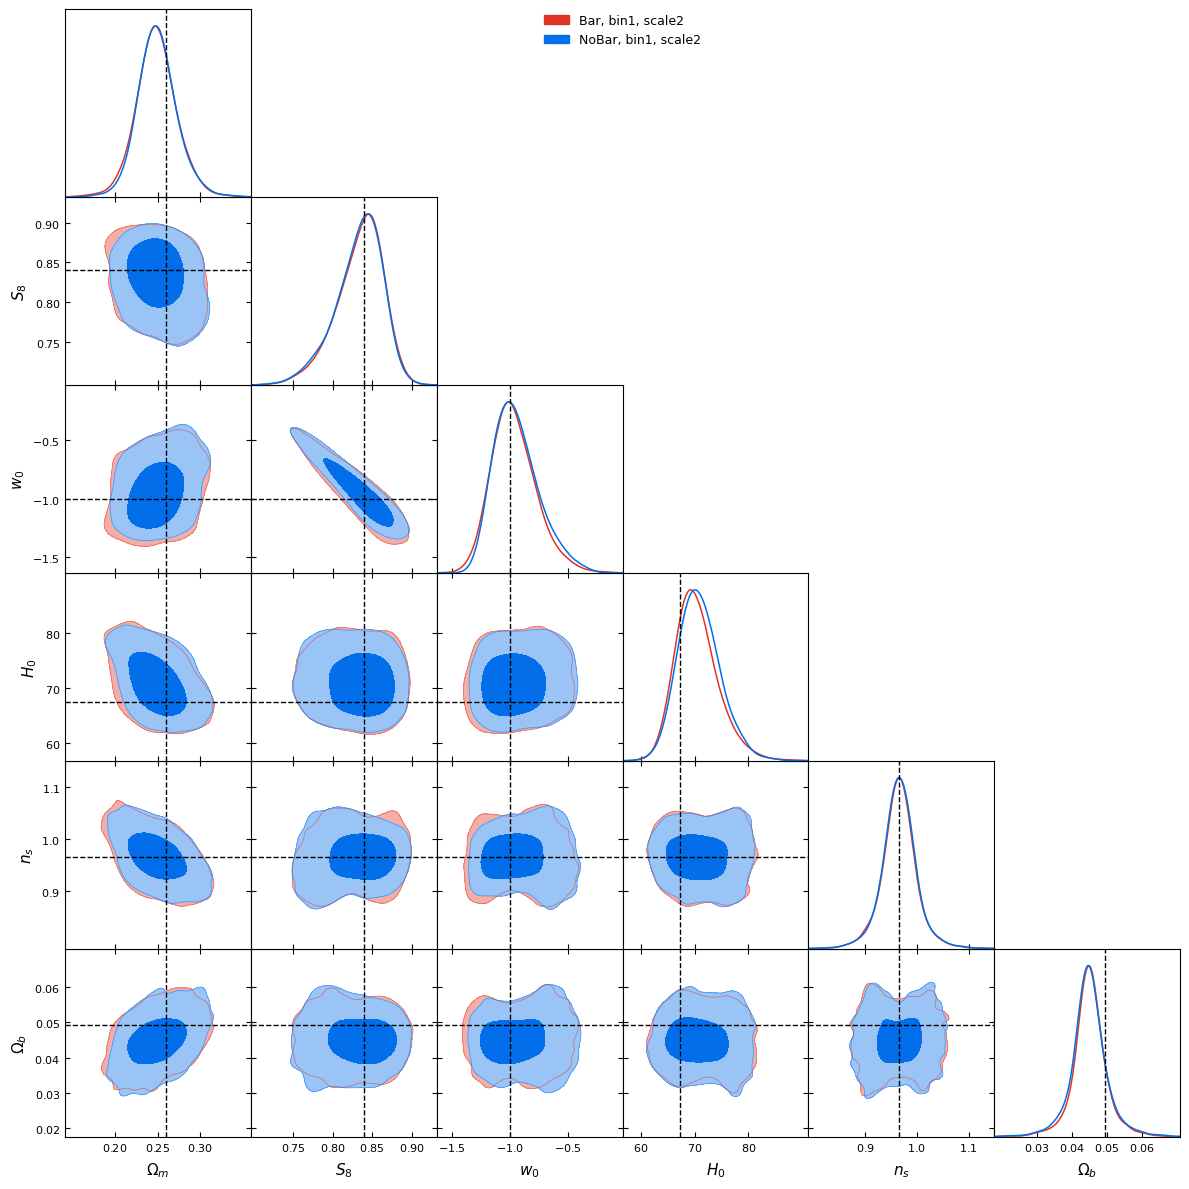

In [17]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples2_bar, samples2_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/NoBar_vs_bar_bin1_scale2_npe.pdf")
plt.show()

# Get biased contours

## NoBar training data vs Bar fid obs

In [2]:
params = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params.npy', allow_pickle=True)

# **BIN 1**

In [3]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms.npy', allow_pickle=True)

In [4]:
params.shape, l1_full.shape

((16965, 6), (16965, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16965, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scale1"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -11.165/ Best val loss -11.175:  26%|██▌       | 259/1000 [01:29<04:16,  2.89it/s]

Neural network training stopped after 260 epochs.
Early stopping with best validation metric: -11.174956321716309
Best model saved at epoch 239
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -11.386465072631836
[!] Validation loss: -11.174956321716309
[!] Test loss: -11.185745239257812


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [12]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1.npy', allow_pickle=True)

In [13]:
np.array(fid_full).shape

(200, 5, 40)

In [14]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [15]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [16]:
import jax.random as random

master_key = random.PRNGKey(1)

In [17]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [18]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [19]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


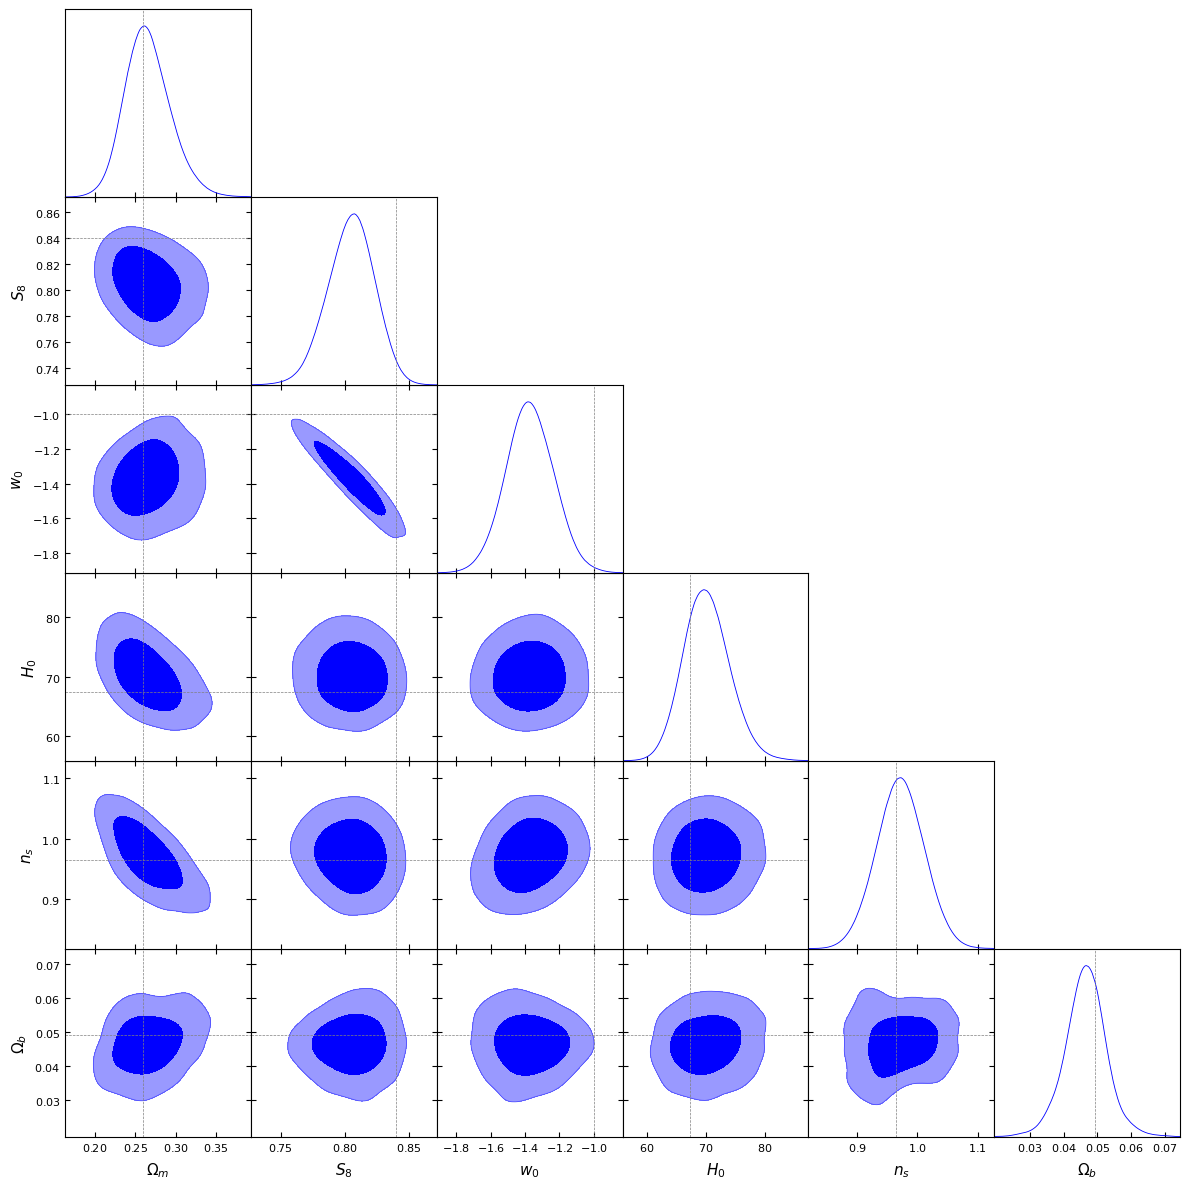

In [20]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [21]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin1_nobar_training_bar_fid_npe.npy", samples_gd_scale1.samples)

## Scale 2

In [22]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [23]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)

In [24]:
dataset = (params, l1_scale2)

In [25]:
inference = NPE()

In [26]:
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [27]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scale2"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -8.881/ Best val loss -8.886:  28%|██▊       | 275/1000 [01:33<04:06,  2.94it/s]

Neural network training stopped after 276 epochs.
Early stopping with best validation metric: -8.886394500732422
Best model saved at epoch 255
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.959028244018555
[!] Validation loss: -8.886394500732422
[!] Test loss: -8.887674331665039


In [28]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [29]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1.npy', allow_pickle=True)

In [30]:
np.array(fid_full).shape

(200, 5, 40)

In [31]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [32]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [33]:
import jax.random as random

master_key = random.PRNGKey(1)

In [34]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [35]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [36]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


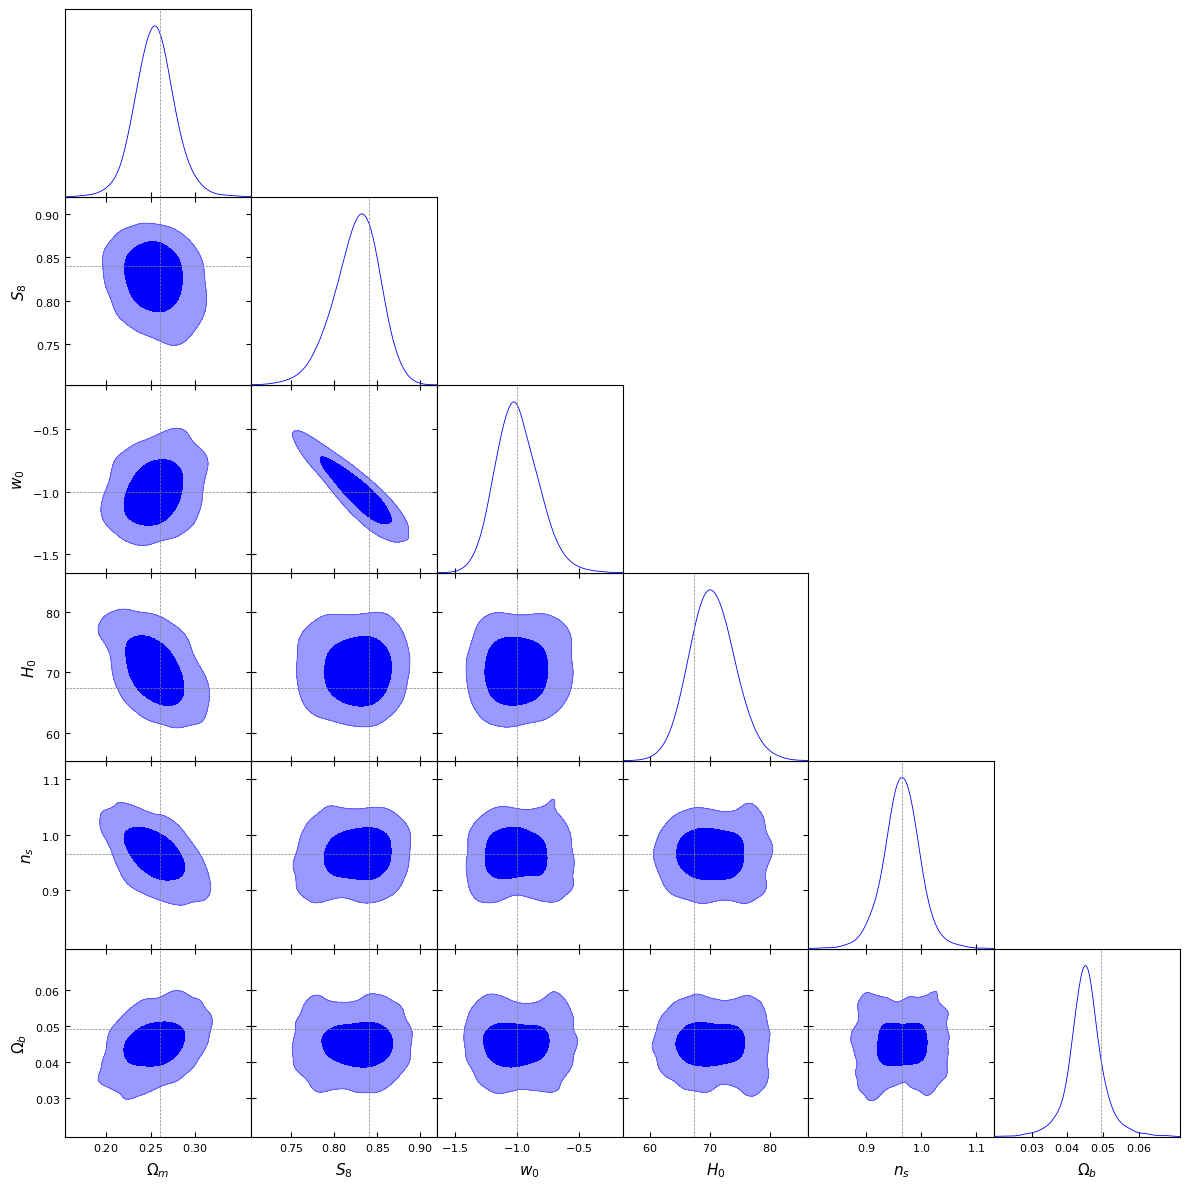

In [37]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [39]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin1_nobar_training_bar_fid_npe.npy", samples_gd_scale2.samples)

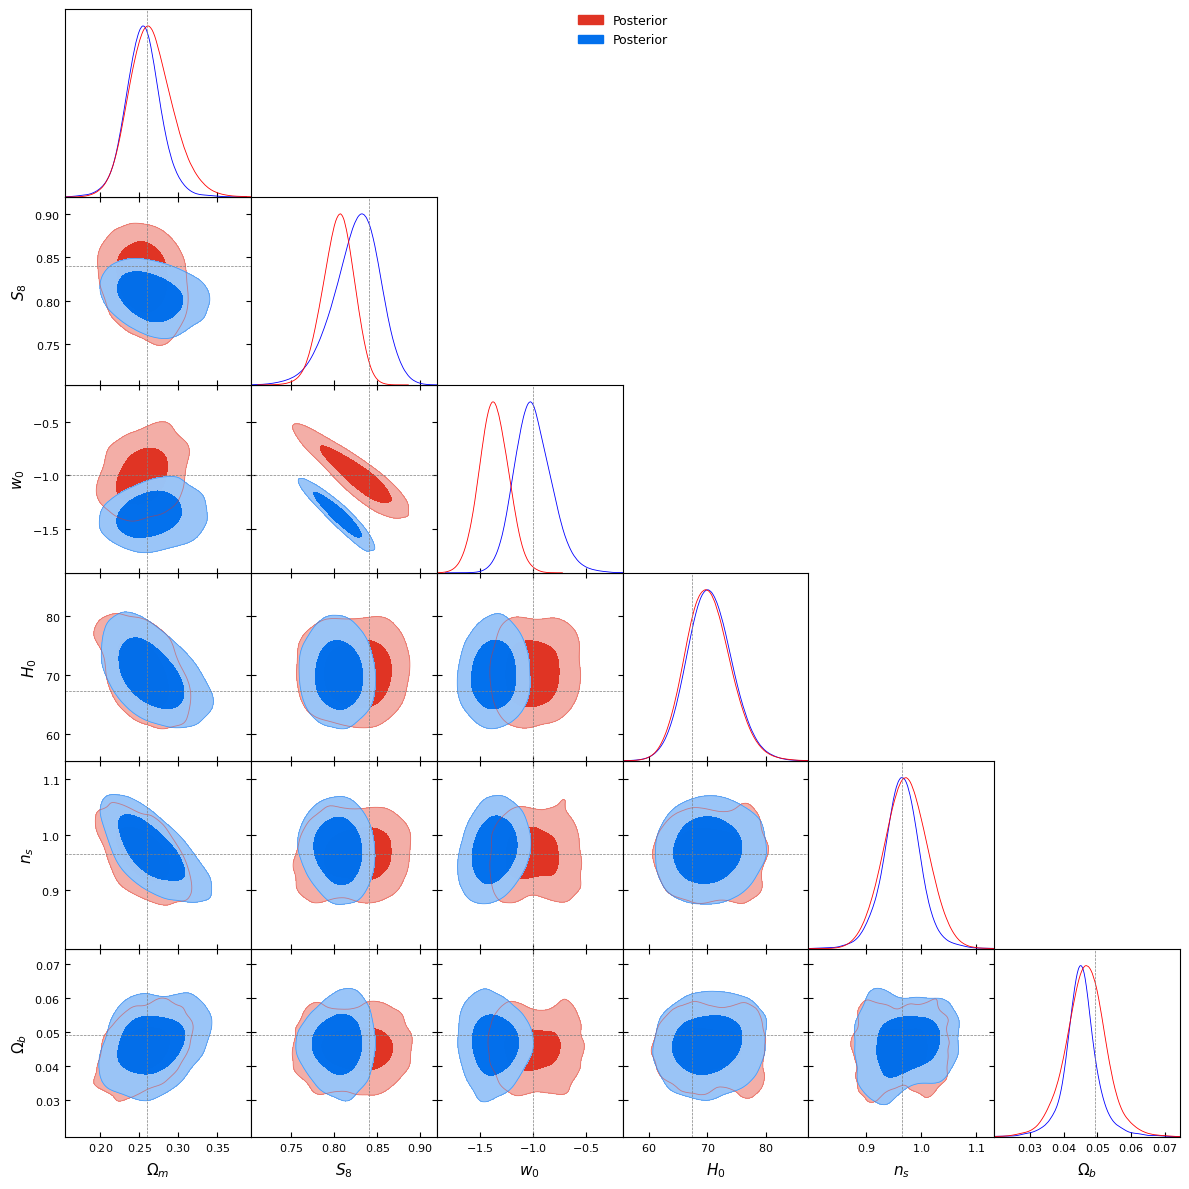

In [41]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_gd_scale2, samples_gd_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()